# Forest clustering comparison on Titanic

This notebook compares the original `ForestClusterer`, the three added tree-based estimators, and two sklearn baselines on a local Titanic sample.

Algorithms compared:
- `ForestClusterer` - existing random partition embedding implementation.
- `UnsupervisedRandomForestClusterer` - Breiman-style real-vs-synthetic random forest proximity.
- `ExtraTreesProximityClusterer` - ExtraTrees real-vs-synthetic leaf proximity.
- `UnsupervisedBinaryTreeClusterer` - greedy unsupervised CART-like binary partition tree.
- `KMeans` and `AgglomerativeClustering` - sklearn baselines on the same preprocessed features.

Metrics are smoke/comparison diagnostics, not a claim that Titanic survival is the correct clustering target. `ARI_vs_survived` is included only as an external sanity check.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from forest_clustering import (
    ForestClusterer,
    UnsupervisedRandomForestClusterer,
    ExtraTreesProximityClusterer,
    UnsupervisedBinaryTreeClusterer,
)

np.set_printoptions(precision=4, suppress=True)
print('Project root:', PROJECT_ROOT)


Project root: /Users/vikozlov/Repos/forest_clustering


In [2]:
TITANIC_CANDIDATES = [
    PROJECT_ROOT / 'data' / 'titanic.csv',
]
TITANIC_URL = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'

for path in TITANIC_CANDIDATES:
    if path.exists():
        df = pd.read_csv(path)
        print('Loaded Titanic from:', path)
        break
else:
    df = pd.read_csv(TITANIC_URL)
    print('Loaded Titanic from:', TITANIC_URL)

wanted = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
cols = [c for c in wanted if c in df.columns]
X = df[cols].head(300).copy()
y_survived = df['Survived'].head(300).to_numpy() if 'Survived' in df.columns else None

print('Shape:', X.shape)
display(X.head())
print('Missing values:')
display(X.isna().sum().to_frame('missing'))


Loaded Titanic from: https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
Shape: (300, 7)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


Missing values:


,missing
Pclass,0
Sex,0
Age,58
SibSp,0
Parch,0
Fare,0
Embarked,1


In [3]:
def make_onehot():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

numeric_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
categorical_cols = [c for c in X.columns if c not in numeric_cols]

preprocessor = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', make_onehot())]), categorical_cols),
], remainder='drop')

X_eval = preprocessor.fit_transform(X)
if hasattr(X_eval, 'toarray'):
    X_eval = X_eval.toarray()
print('Evaluation matrix shape:', X_eval.shape)


Evaluation matrix shape: (300, 10)


In [4]:
def safe_silhouette(X_eval, labels):
    unique = np.unique(labels)
    if len(unique) < 2 or len(unique) >= len(labels):
        return np.nan
    return silhouette_score(X_eval, labels)

def model_summary(name, labels, fit_obj=None):
    labels = np.asarray(labels)
    row = {
        'algorithm': name,
        'n_clusters_found': int(len(np.unique(labels))),
        'cluster_sizes': dict(zip(*np.unique(labels, return_counts=True))),
        'silhouette': safe_silhouette(X_eval, labels),
        'calinski_harabasz': calinski_harabasz_score(X_eval, labels) if len(np.unique(labels)) > 1 else np.nan,
        'davies_bouldin': davies_bouldin_score(X_eval, labels) if len(np.unique(labels)) > 1 else np.nan,
    }
    if y_survived is not None:
        row['ARI_vs_survived'] = adjusted_rand_score(y_survived, labels)
        row['NMI_vs_survived'] = normalized_mutual_info_score(y_survived, labels)
    if fit_obj is not None and hasattr(fit_obj, 'proximity_matrix'):
        P = fit_obj.proximity_matrix()
        row['proximity_shape'] = str(P.shape)
        row['proximity_diag_mean'] = float(np.diag(P).mean())
    return row


In [5]:
models = []

# Existing library estimator. Use conservative settings so the smoke run is fast and deterministic.
models.append(('ForestClusterer', ForestClusterer(n_iterations=30, n_bins=4, n_clusters=3, random_state=123, corr_threshold=None, n_jobs=1)))
models.append(('Breiman URF', UnsupervisedRandomForestClusterer(n_estimators=60, n_clusters=3, min_samples_leaf=2, random_state=123, n_jobs=1)))
models.append(('ExtraTrees Proximity', ExtraTreesProximityClusterer(n_estimators=60, n_clusters=3, min_samples_leaf=2, random_state=123, n_jobs=1)))
models.append(('Unsupervised Binary Tree', UnsupervisedBinaryTreeClusterer(n_clusters=3, min_samples_leaf=10, min_samples_split=20, max_depth=5, n_thresholds=16, random_state=123)))

rows = []
labels_by_name = {}
for name, model in models:
    labels = model.fit_predict(X)
    labels_by_name[name] = labels
    rows.append(model_summary(name, labels, model))
    print(f'{name}: labels={np.unique(labels).tolist()}, sizes={dict(zip(*np.unique(labels, return_counts=True)))}')

# sklearn baselines on identical preprocessed features
km = KMeans(n_clusters=3, random_state=123, n_init=10)
labels = km.fit_predict(X_eval)
labels_by_name['sklearn KMeans'] = labels
rows.append(model_summary('sklearn KMeans', labels))

try:
    agg = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
except TypeError:
    agg = AgglomerativeClustering(n_clusters=3, affinity='euclidean', linkage='ward')
labels = agg.fit_predict(X_eval)
labels_by_name['sklearn Agglomerative Ward'] = labels
rows.append(model_summary('sklearn Agglomerative Ward', labels))

results = pd.DataFrame(rows)
# Make dict columns readable in both notebook and PDF.
results['cluster_sizes'] = results['cluster_sizes'].map(lambda d: ', '.join(f'{k}: {v}' for k, v in d.items()))
display(results)


ForestClusterer: labels=[0, 1, 2], sizes={np.int32(0): np.int64(111), np.int32(1): np.int64(55), np.int32(2): np.int64(134)}
Breiman URF: labels=[0, 1, 2], sizes={np.int64(0): np.int64(155), np.int64(1): np.int64(95), np.int64(2): np.int64(50)}


ExtraTrees Proximity: labels=[0, 1, 2], sizes={np.int64(0): np.int64(194), np.int64(1): np.int64(91), np.int64(2): np.int64(15)}


Unsupervised Binary Tree: labels=[0, 1, 2], sizes={np.int64(0): np.int64(64), np.int64(1): np.int64(179), np.int64(2): np.int64(57)}


,algorithm,n_clusters_found,cluster_sizes,silhouette,calinski_harabasz,davies_bouldin,ARI_vs_survived,NMI_vs_survived,proximity_shape,proximity_diag_mean
0,ForestClusterer,3,"0: 111, 1: 55, 2: 134",0.180619,61.047085,1.935603,0.043032,0.028068,NaN,NaN
1,Breiman URF,3,"0: 155, 1: 95, 2: 50",0.139294,66.058532,1.694836,0.001822,0.014505,"(300, 300)",1.0
2,ExtraTrees Proximity,3,"0: 194, 1: 91, 2: 15",0.035050,19.471010,2.269767,0.321724,0.223581,"(300, 300)",1.0
3,Unsupervised Binary Tree,3,"0: 64, 1: 179, 2: 57",0.329706,94.201990,1.334474,0.048718,0.018580,"(300, 300)",1.0
4,sklearn KMeans,3,"0: 192, 1: 68, 2: 40",0.343431,102.436268,1.240891,0.039224,0.013858,NaN,NaN
5,sklearn Agglomerative Ward,3,"0: 78, 1: 56, 2: 166",0.309131,91.042834,1.342124,0.018485,0.005662,NaN,NaN


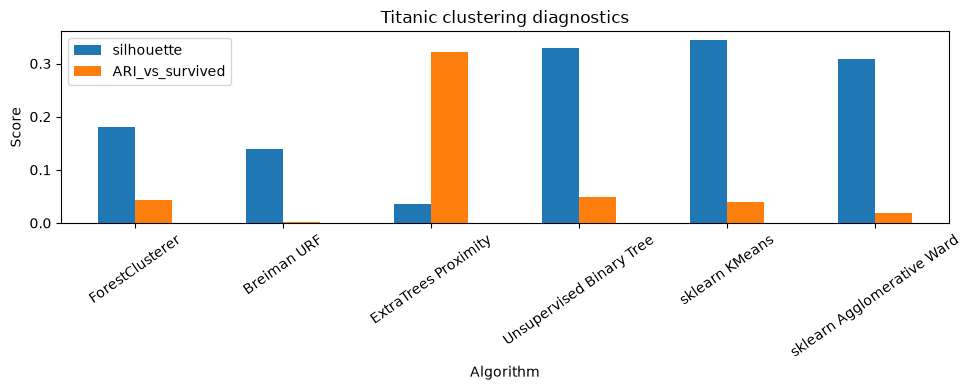

In [6]:
plot_df = results.set_index('algorithm')[['silhouette', 'ARI_vs_survived' if y_survived is not None else 'calinski_harabasz']]
ax = plot_df.plot(kind='bar', figsize=(10, 4), rot=35)
ax.set_title('Titanic clustering diagnostics')
ax.set_xlabel('Algorithm')
ax.set_ylabel('Score')
plt.tight_layout()
plt.show()


In [7]:
# Pairwise ARI between algorithm outputs: useful to see whether methods partition data similarly.
names = list(labels_by_name)
ari_matrix = pd.DataFrame(index=names, columns=names, dtype=float)
for a in names:
    for b in names:
        ari_matrix.loc[a, b] = adjusted_rand_score(labels_by_name[a], labels_by_name[b])
display(ari_matrix.round(3))


,ForestClusterer,Breiman URF,ExtraTrees Proximity,Unsupervised Binary Tree,sklearn KMeans,sklearn Agglomerative Ward
ForestClusterer,1.000,0.269,0.070,0.476,0.363,0.386
Breiman URF,0.269,1.000,0.084,0.277,0.256,0.282
ExtraTrees Proximity,0.070,0.084,1.000,0.045,0.012,0.014
Unsupervised Binary Tree,0.476,0.277,0.045,1.000,0.739,0.799
sklearn KMeans,0.363,0.256,0.012,0.739,1.000,0.705
sklearn Agglomerative Ward,0.386,0.282,0.014,0.799,0.705,1.000


In [8]:
bt = [m for name, m in models if name == 'Unsupervised Binary Tree'][0]
rules_df = pd.DataFrame(bt.rules())
display(rules_df)


,leaf,n_samples,rule
0,0,64,num__Pclass <= -1.07449
1,1,179,num__Pclass > -1.07449 and num__Parch <= 0.142731
2,2,57,num__Pclass > -1.07449 and num__Parch > 0.142731


## Interpretation

The tree-proximity estimators expose a proximity/distance API, while sklearn baselines cluster directly in the same preprocessed feature space. The binary tree is the most interpretable of the new methods because each cluster has an explicit root-to-leaf rule. The RF/ExtraTrees methods usually provide richer proximities because each sample pair is compared across many leaf partitions rather than a single terminal leaf.
